In [1]:
import pandas as pd
import pickle as pkl
import json
import numpy as np
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

In [2]:
# load in test data
with open('../data/processed/df_tabular_test.pkl', 'rb') as f:
    df = pkl.load(f)

In [3]:
# load in the model - just use XGBOost for now
with open('../models/XGBoost.pkl', 'rb') as f:
    model = pkl.load(f)

In [4]:
with open('../data/processed/mean_std_per_client.json', 'r') as f:
    df_std_mean_usage = pd.read_json(f).T
    # create dictionary version for fast lookup
    dict_std_mean_usage = df_std_mean_usage.to_dict(orient='index')

In [ ]:
# for now get one client
client_to_pick = 277
df_one_client = df[df.index.get_level_values('client_id') == client_to_pick]




X_test = df_one_client.drop(columns=['hourly_usage_kwh'])
y_test = df_one_client['hourly_usage_kwh']

In [8]:
# get datetimes at 6am
datetimes = y_test.index.get_level_values('datetime')
datetimes_forecast_start = datetimes[datetimes.hour == 6]

In [ ]:
# forecast horizon of 24 hours
HORIZON = 24

# need to get indexes corresponding to each column
col_idxs = {col: i for i, col in enumerate(X_test.columns)}
col_idxs

{'hour_sin': 0,
 'hour_cos': 1,
 'day_sin': 2,
 'day_cos': 3,
 'month_sin': 4,
 'month_cos': 5,
 'lag_1hr': 6,
 'lag_2hr': 7,
 'lag_6hr': 8,
 'lag_1dy': 9,
 'lag_1wk': 10,
 'rolling_mean_1dy': 11,
 'rolling_mean_1wk': 12,
 'rolling_max_1dy': 13,
 'rolling_max_1wk': 14,
 'rolling_min_1dy': 15,
 'rolling_min_1wk': 16,
 'rolling_std_1dy': 17,
 'rolling_std_1wk': 18,
 'mean_usage': 19}

In [54]:
# convert x and y to array
X_test_array = X_test.to_numpy()
y_test_array = y_test.to_numpy()

# get the number of context windows for testing (requires at least month of prior data)
starting_dates_for_test = datetimes_forecast_start[28:-1]
num_context_windows = len(starting_dates_for_test)

# create matrix for the predictions (context windows and hours of day)
# will get datetime corresponding to each context window later
y_preds_array = np.zeros((num_context_windows, HORIZON))


In [68]:
def update_the_feature_array(initial_features_indexes, hour_index):

    """ take the index of data to collect and recompute lag and rolling features, ready for 
    prediction """
    
    # get exisiting feature values at each initial forecast step (using single step
    # engineered features as baseline) 
    feature_array = X_test_array[initial_features_indexes + hour_index, :]

    # expand dims for indexes so can broadcast later when want range of indexes
    initial_features_indexes = np.expand_dims(initial_features_indexes, axis=-1)

    # use np.arange to extract contigous indexes (i.e., window; first axis) for each context window (zeroth axis)
    data_from_target = y_test_array[initial_features_indexes + hour_index - 168 + np.arange(168 - hour_index)]
    # then get data from preds
    data_from_preds = y_preds_array[:, np.arange(hour_index)]
    # then combine
    data_to_process = np.concat((data_from_target, data_from_preds), axis=-1)

    # recompute lag features
    feature_array[:, col_idxs['lag_1hr']] = data_to_process[:, -1]
    feature_array[:, col_idxs['lag_2hr']] = data_to_process[:, -2]
    feature_array[:, col_idxs['lag_6hr']] = data_to_process[:, -6]
    feature_array[:, col_idxs['lag_1dy']] = data_to_process[:, -24]
    feature_array[:, col_idxs['lag_1wk']] = data_to_process[:, -168]

    # and the rolling features
    feature_array[:, col_idxs['rolling_mean_1dy']] = np.mean(data_to_process[:, -24:])
    feature_array[:, col_idxs['rolling_mean_1wk']] = np.mean(data_to_process[:, -168:])

    feature_array[:, col_idxs['rolling_max_1dy']] = np.max(data_to_process[:, -24:])
    feature_array[:, col_idxs['rolling_max_1wk']] = np.max(data_to_process[:, -168:])

    feature_array[:, col_idxs['rolling_min_1dy']] = np.min(data_to_process[:, -24:])
    feature_array[:, col_idxs['rolling_min_1wk']] = np.min(data_to_process[:, -168:])

    return feature_array

In [ ]:
# NOTE: currently only set up for one client
############
# get indexes of first forecast datetimes within the testing data array
initial_features_indexes = X_test.index.droplevel('client_id').get_indexer(starting_dates_for_test)


# loop over each hour to forecast (index zero starts at 6am)
for hour_index in range(HORIZON):

    if hour_index == 0:
        # if hour is zero, then just take the feature values from test data (already in correct order)
        feature_array = X_test.iloc[initial_features_indexes].values
    else:
        # otherwise concat exisiting observed data with predictions (recursive step)
        feature_array = update_the_feature_array(initial_features_indexes=initial_features_indexes, 
                                                 hour_index=hour_index)
    
    # update the predictions matrix
    y_preds_array[:, hour_index] = model.predict(feature_array)


In [ ]:
# create datetime array for the datetimes that have predicted
datetimes_preds = pd.date_range(datetimes_forecast_start[28], datetimes_forecast_start[-1] - pd.Timedelta('1 hour'), freq='h')

In [ ]:
# create dataframe for predictions
y_preds_df = pd.DataFrame(data=y_preds_array.flatten(), index=datetimes_preds, columns=['y_pred'])

# set name of index column
y_preds_df.index.name = 'datetime'

# filter into testing data to get actual values
y_preds_df['y_label'] = y_test[y_test.index.get_level_values('datetime').isin(datetimes_preds)].droplevel('client_id')

# unscale the target and predictions
y_preds_df = y_preds_df * dict_std_mean_usage[client_to_pick]['std'] + dict_std_mean_usage[client_to_pick]['mean']

In [ ]:
# compute rmse for each hour
rmse_each_hour = y_preds_df.groupby(datetimes_preds.hour).apply(lambda g: root_mean_squared_error(y_true=g['y_label'], y_pred=g['y_pred']))

# divide by mean usage for nrmse for each hour
nrmse_per_hour = rmse_each_hour/dict_std_mean_usage[client_to_pick]['mean']
nrmse_per_hour

Now get predictions from single timestep model to compare

In [ ]:
# get predictions from single timestep prediction
y_preds_single_step = model.predict(X_test[X_test.index.get_level_values('datetime').isin(datetimes_preds)])

# unscale the predcition
y_preds_single_step_unscaled = y_preds_single_step * dict_std_mean_usage[client_to_pick]['std'] + dict_std_mean_usage[client_to_pick]['mean']

# create df from predictions
df_single_preds = pd.DataFrame(data={'y_pred': y_preds_single_step_unscaled, 'y_label': y_preds_df['y_label']}, index=y_preds_df.index)

In [ ]:
# and compute rmse per hour again
rmse_each_hour_single = df_single_preds.groupby(datetimes_preds.hour).apply(lambda g: root_mean_squared_error(y_true=g['y_label'], y_pred=g['y_pred']))

# and nrmse
nrmse_each_hour_single = rmse_each_hour_single / dict_std_mean_usage[client_to_pick]['mean']
nrmse_each_hour_single

Plotting


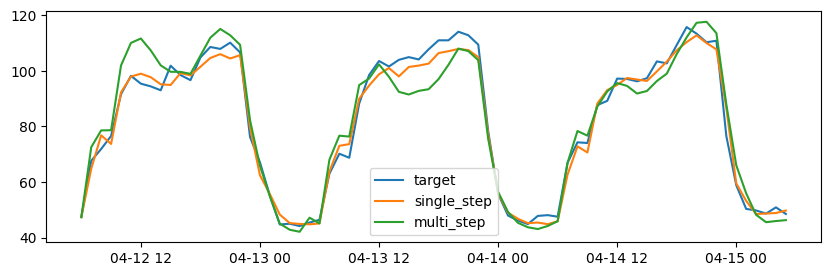

In [69]:
datetimes_to_plot = datetimes_preds[:72]


plt.figure(figsize=(10, 3))
plt.plot(datetimes_to_plot, df_single_preds['y_label'].iloc[:72], label='target')
plt.plot(datetimes_to_plot, df_single_preds['y_pred'].iloc[:72], label='single_step')
plt.plot(datetimes_to_plot, y_preds_df['y_pred'].iloc[:72], label='multi_step')
plt.legend()
plt.show()